# 04 - Allen-Cahn Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \varepsilon^2 u_{xx} + u - u^3$, $\varepsilon = 0.01$

**IC:** $u(x,0) = x^2 \cos(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 128, 128, 128, 128, 128, 1]` | **Epochs:** 10000

**Note:** Allen-Cahn is the hardest test. Stiff PDE with sharp interface.
Vanilla PINN is known to fail here. This is AC-PINN's strongest showcase.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    AllenCahnFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'allen_cahn'
LAYERS     = [2, 128, 128, 128, 128, 128, 1]
EPOCHS     = 10000
PDE_PARAMS = {'epsilon': 0.01}
RESULTS    = '../results/allen_cahn/'
FIGURES    = '../figures/allen_cahn/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

AllenCahnFDM solved in 1.5561s


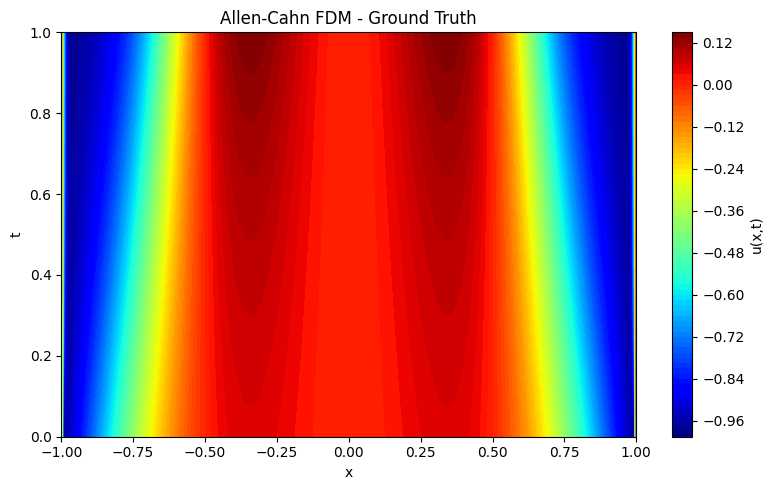

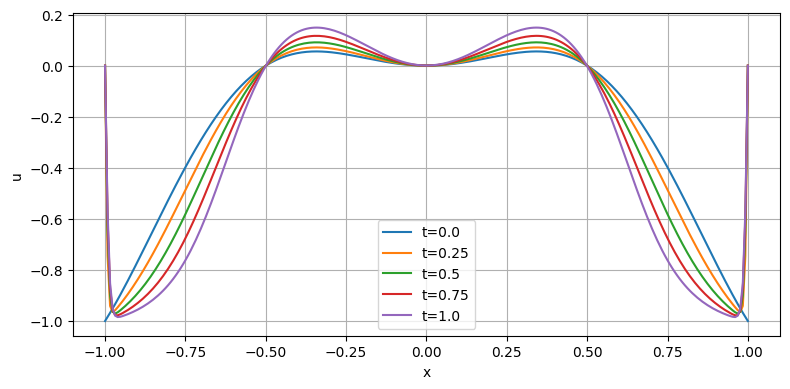

In [2]:
fdm = AllenCahnFDM(nx=256, nt=5000, epsilon=0.01)
fdm.solve()
fdm.plot_solution(title='Allen-Cahn FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
# Allen-Cahn needs more collocation points due to stiffness
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=10000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=3000,  noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Allen-Cahn | Vanilla Clean | Epoch     0/10000] Total: 0.186492 | IC: 0.138605 | BC: 0.013563 | PDE: 0.003432


[Allen-Cahn | Vanilla Clean | Epoch  1000/10000] Total: 0.127919 | IC: 0.121206 | BC: 0.003752 | PDE: 0.000296


[Allen-Cahn | Vanilla Clean | Epoch  2000/10000] Total: 0.127720 | IC: 0.121179 | BC: 0.003589 | PDE: 0.000295


[Allen-Cahn | Vanilla Clean | Epoch  3000/10000] Total: 0.131756 | IC: 0.122879 | BC: 0.007291 | PDE: 0.000159


...

[Allen-Cahn | Vanilla Clean | Epoch  6000/10000] Total: 0.026376 | IC: 0.022443 | BC: 0.001038 | PDE: 0.000290


[Allen-Cahn | Vanilla Clean | Epoch  7000/10000] Total: 0.019645 | IC: 0.016711 | BC: 0.001047 | PDE: 0.000189


[Allen-Cahn | Vanilla Clean | Epoch  8000/10000] Total: 0.015921 | IC: 0.013754 | BC: 0.000736 | PDE: 0.000143


[Allen-Cahn | Vanilla Clean | Epoch  9000/10000] Total: 0.013256 | IC: 0.011420 | BC: 0.000623 | PDE: 0.000121



Training complete in 254.59s


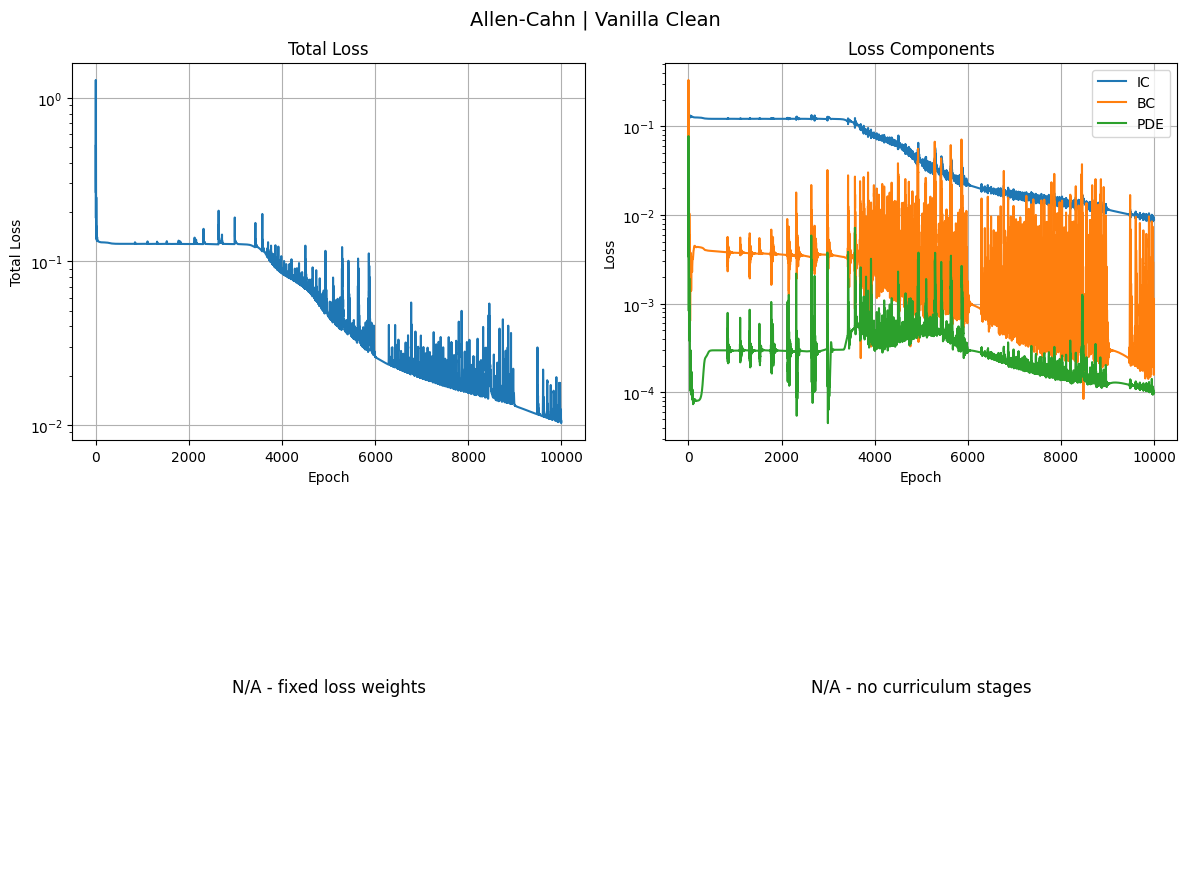

Saved: ../figures/allen_cahn/vanilla_clean_training.png
Saved: ../figures/allen_cahn/vanilla_clean_training.csv


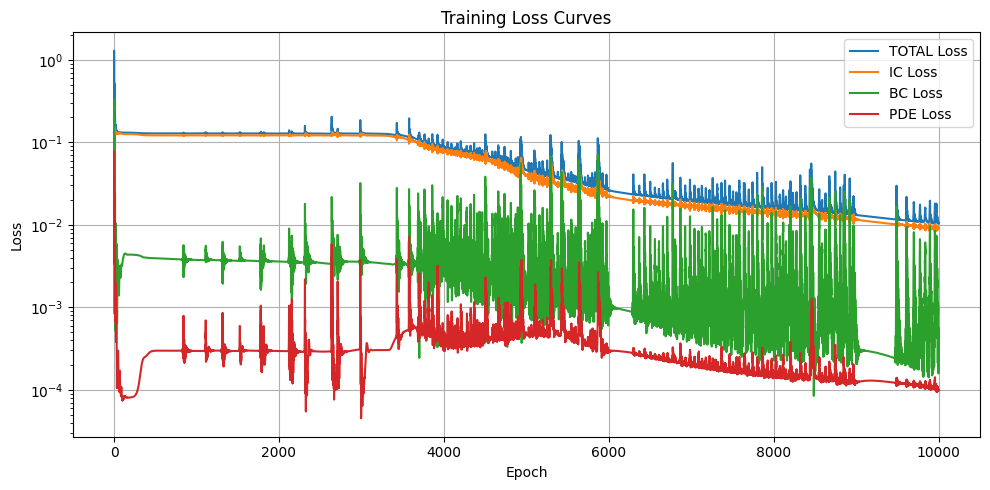

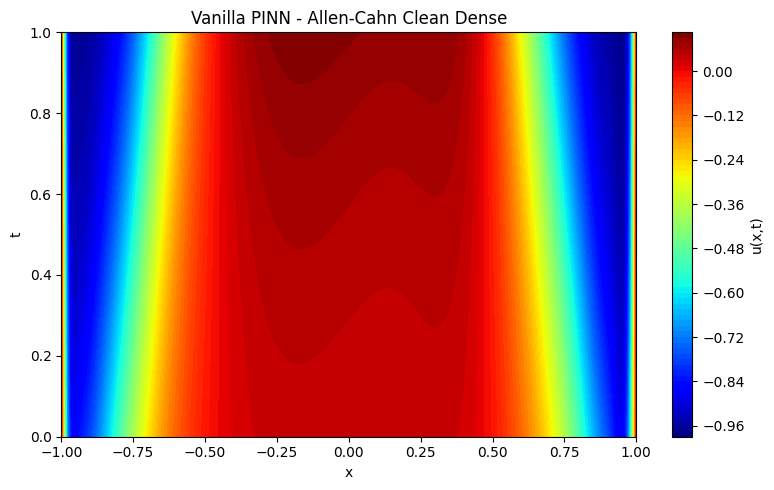

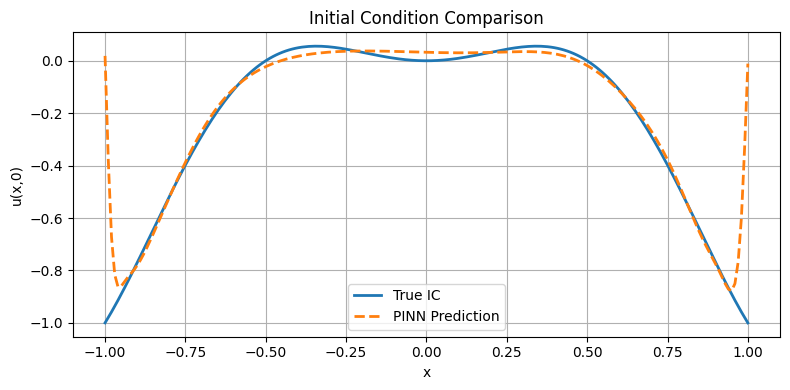

Saved: ../results/allen_cahn/vanilla_clean_history.npy


In [4]:
# Higher lambda_pde for stiff PDE
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Allen-Cahn | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Allen-Cahn Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse
⚠️ Vanilla PINN typically fails here on Allen-Cahn.

[Allen-Cahn | Vanilla Noisy | Epoch     0/10000] Total: 0.281125 | IC: 0.111969 | BC: 0.059773 | PDE: 0.010938


[Allen-Cahn | Vanilla Noisy | Epoch  1000/10000] Total: 0.116376 | IC: 0.092848 | BC: 0.022522 | PDE: 0.000101


[Allen-Cahn | Vanilla Noisy | Epoch  2000/10000] Total: 0.116039 | IC: 0.092676 | BC: 0.022328 | PDE: 0.000104


[Allen-Cahn | Vanilla Noisy | Epoch  3000/10000] Total: 0.118646 | IC: 0.089897 | BC: 0.023854 | PDE: 0.000489


[Allen-Cahn | Vanilla Noisy | Epoch  4000/10000] Total: 0.044211 | IC: 0.017523 | BC: 0.021135 | PDE: 0.000555


...

[Allen-Cahn | Vanilla Noisy | Epoch  6000/10000] Total: 0.031601 | IC: 0.009302 | BC: 0.017108 | PDE: 0.000519


[Allen-Cahn | Vanilla Noisy | Epoch  7000/10000] Total: 0.028132 | IC: 0.006017 | BC: 0.019503 | PDE: 0.000261


[Allen-Cahn | Vanilla Noisy | Epoch  8000/10000] Total: 0.023009 | IC: 0.005647 | BC: 0.015663 | PDE: 0.000170


[Allen-Cahn | Vanilla Noisy | Epoch  9000/10000] Total: 0.021966 | IC: 0.005352 | BC: 0.015188 | PDE: 0.000143



Training complete in 132.94s


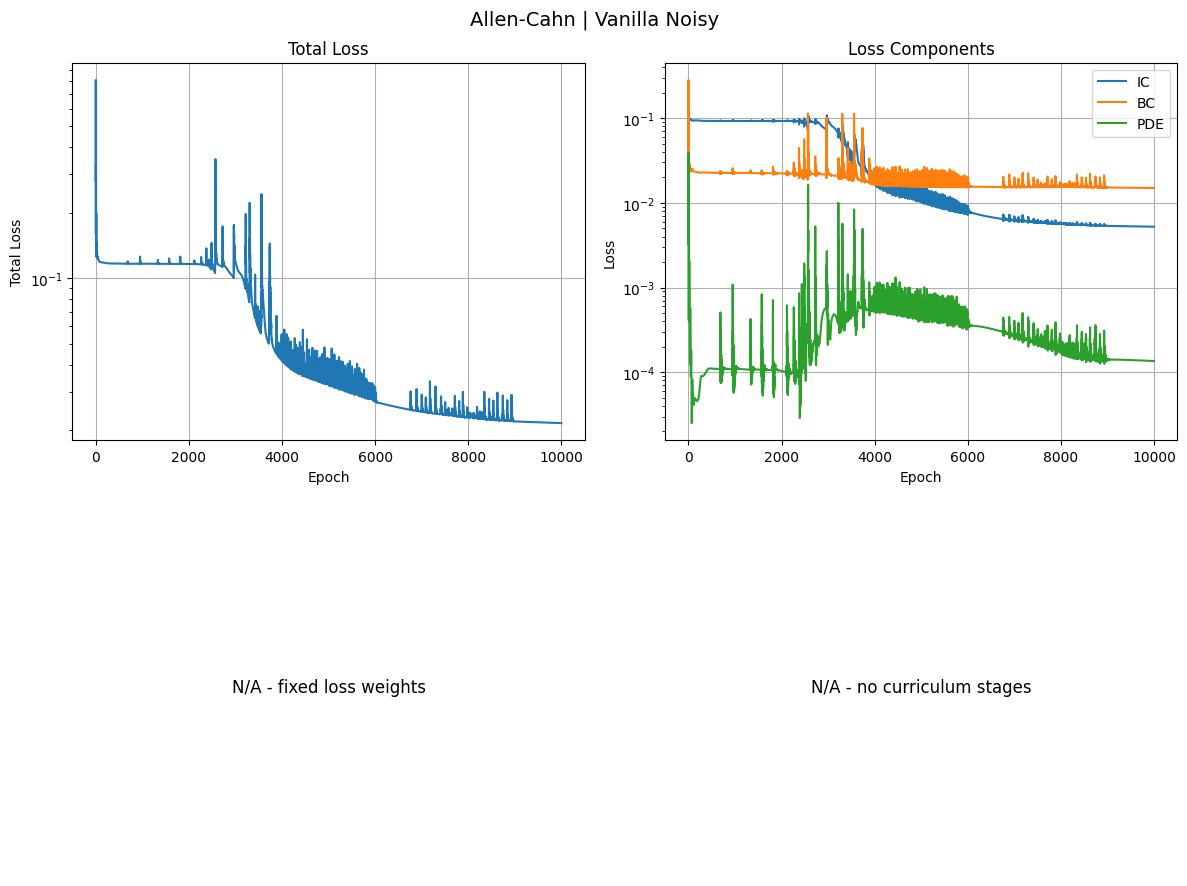

Saved: ../figures/allen_cahn/vanilla_noisy_training.png
Saved: ../figures/allen_cahn/vanilla_noisy_training.csv


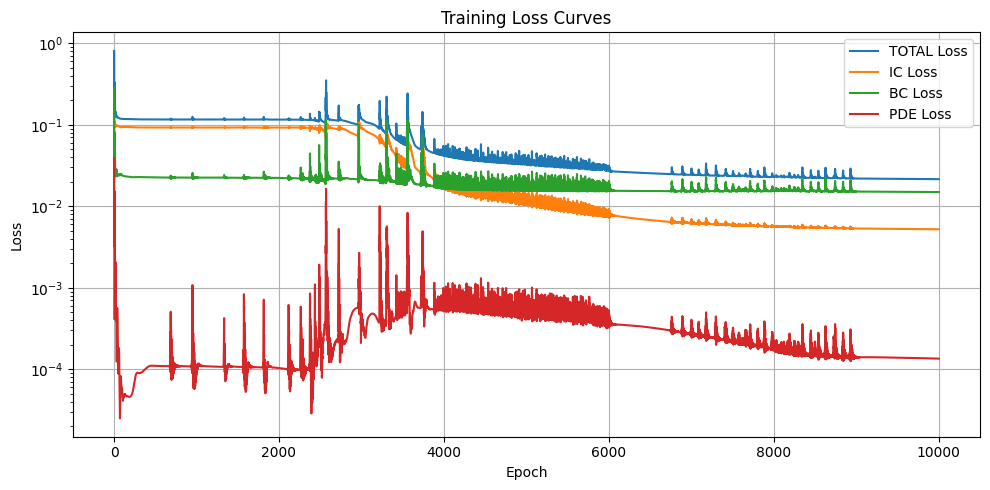

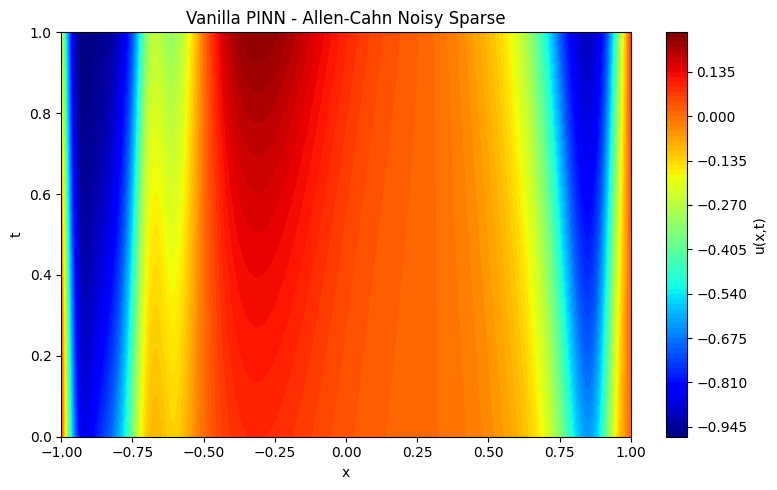

Saved: ../results/allen_cahn/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Allen-Cahn | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Allen-Cahn Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Allen-Cahn | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.147640 | IC: 0.137287 | BC: 0.008799 | PDE: 0.000311 | lam=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.034898 | IC: 0.008875 | BC: 0.006059 | PDE: 0.000049 | lam=(1.47,3.52,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.008416 | IC: 0.002301 | BC: 0.000557 | PDE: 0.000017 | lam=(1.16,10.00,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.006658 | IC: 0.003951 | BC: 0.000114 | PDE: 0.000027 | lam=(1.49,4.59,9.01)


[Allen-Cahn | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.001187 | IC: 0.000467 | BC: 0.000064 | PDE: 0.000001 | lam=(1.21,9.53,10.00)


...

[Allen-Cahn | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000822 | IC: 0.000329 | BC: 0.000262 | PDE: 0.000075 | lam=(1.48,1.18,0.34)


[Allen-Cahn | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000446 | IC: 0.000148 | BC: 0.000168 | PDE: 0.000026 | lam=(1.30,1.47,0.23)


[Allen-Cahn | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.610326 | IC: 0.034625 | BC: 0.024693 | PDE: 0.245270 | lam=(0.34,0.24,2.42)


[Allen-Cahn | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.383007 | IC: 0.128766 | BC: 0.000438 | PDE: 0.000707 | lam=(2.97,0.10,0.10)



AC-PINN training complete in 273.33s


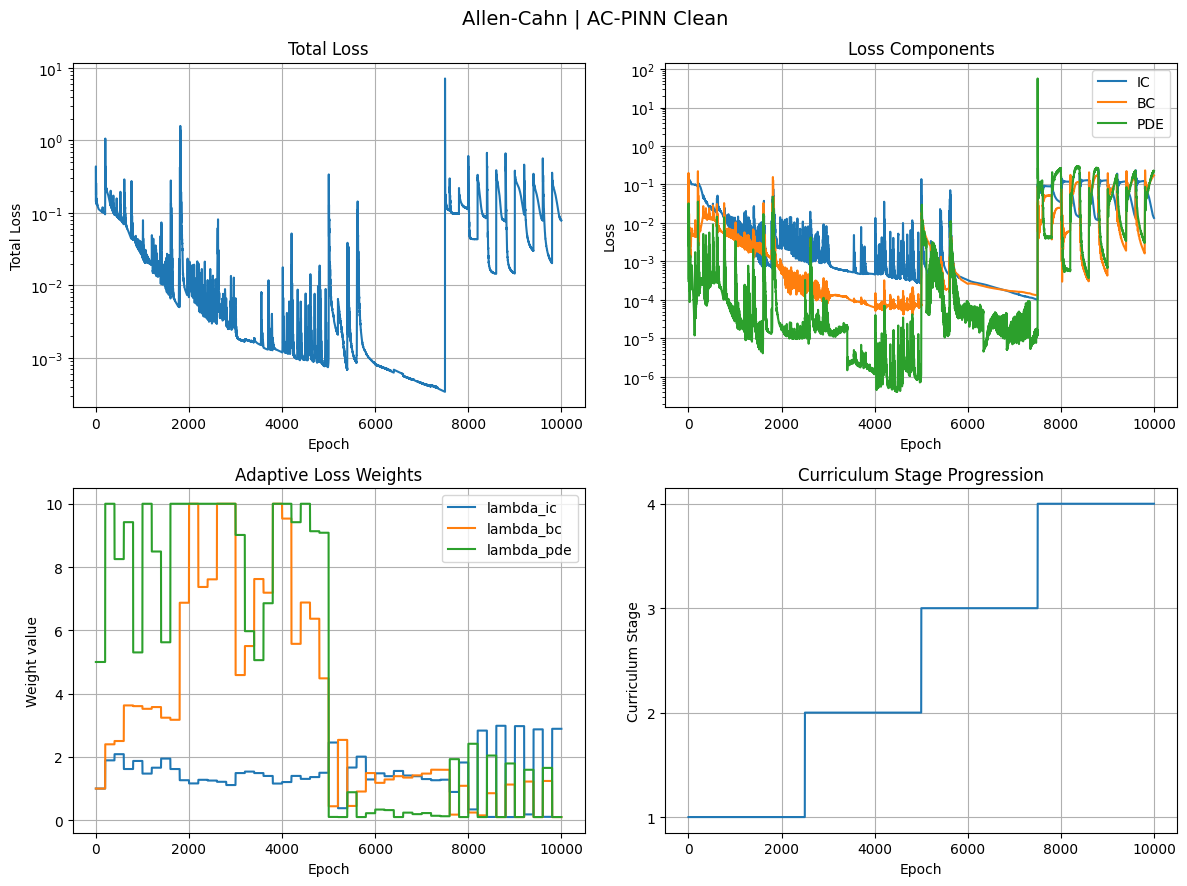

Saved: ../figures/allen_cahn/acpinn_clean_training.png
Saved: ../figures/allen_cahn/acpinn_clean_training.csv


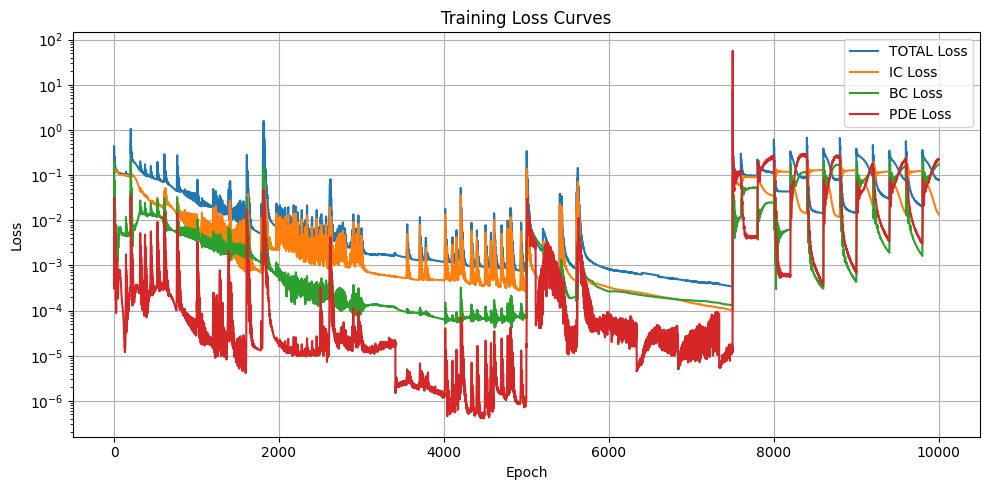

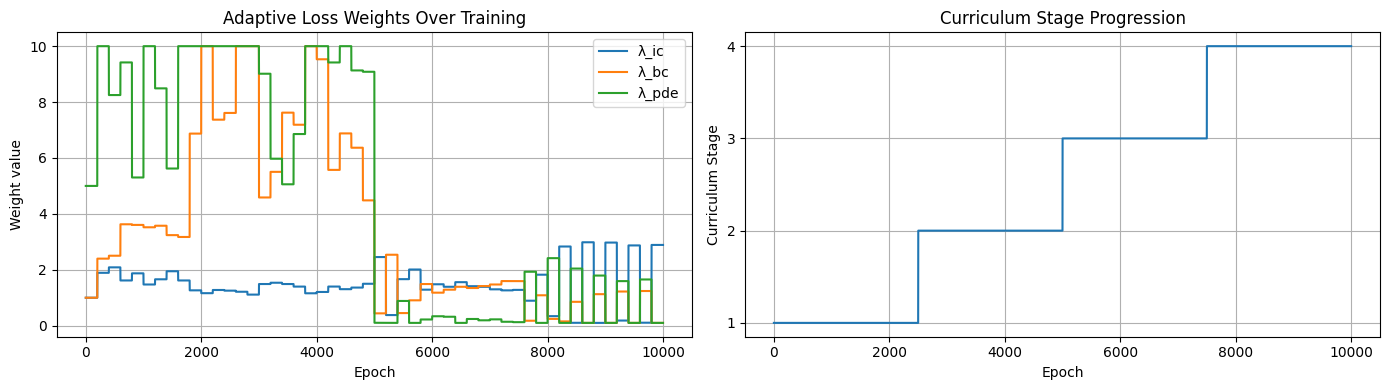

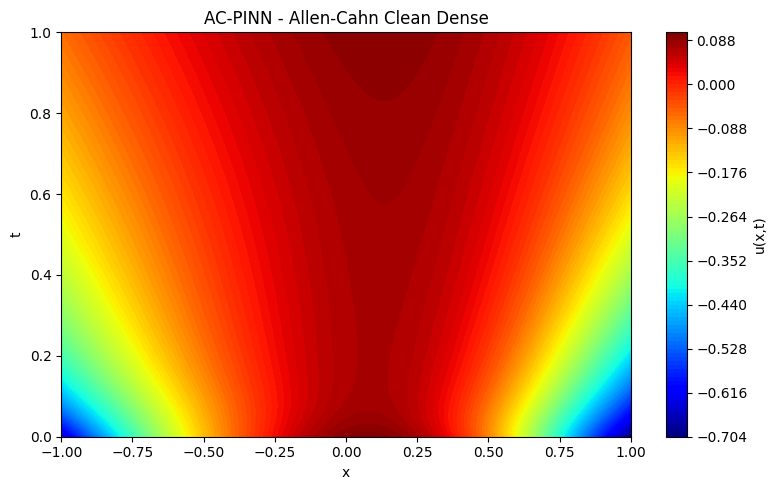

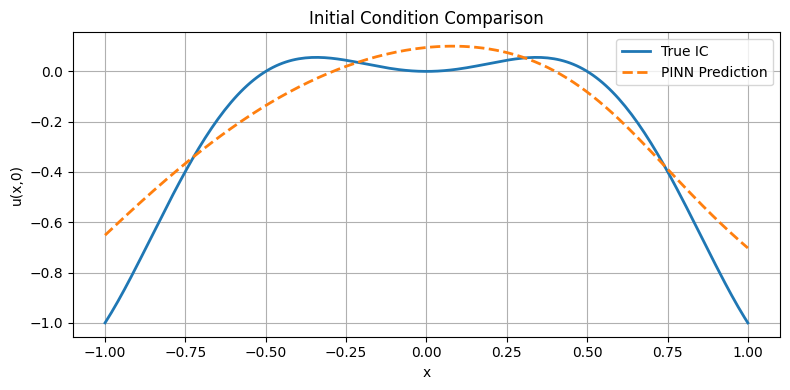

Saved: ../results/allen_cahn/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Allen-Cahn | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Allen-Cahn Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse
This is where AC-PINN should demonstrate its biggest advantage.

[Allen-Cahn | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.140393 | IC: 0.107246 | BC: 0.031863 | PDE: 0.000257 | lam=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.097600 | IC: 0.021657 | BC: 0.015798 | PDE: 0.001211 | lam=(2.17,2.77,5.60)


[Allen-Cahn | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.061220 | IC: 0.006641 | BC: 0.010707 | PDE: 0.000747 | lam=(4.66,2.66,2.44)


[Allen-Cahn | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.060754 | IC: 0.005148 | BC: 0.009917 | PDE: 0.000359 | lam=(4.14,3.91,1.99)


[Allen-Cahn | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.043308 | IC: 0.004814 | BC: 0.008830 | PDE: 0.000129 | lam=(3.50,2.96,2.66)


...

[Allen-Cahn | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.010883 | IC: 0.003935 | BC: 0.004099 | PDE: 0.001428 | lam=(1.25,1.30,0.45)


[Allen-Cahn | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.010083 | IC: 0.003790 | BC: 0.003577 | PDE: 0.001030 | lam=(1.35,1.28,0.37)


[Allen-Cahn | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.063422 | IC: 0.024642 | BC: 0.016338 | PDE: 0.020765 | lam=(1.20,0.79,1.01)


[Allen-Cahn | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.074425 | IC: 0.031163 | BC: 0.014695 | PDE: 0.002184 | lam=(1.95,0.92,0.14)



AC-PINN training complete in 151.26s


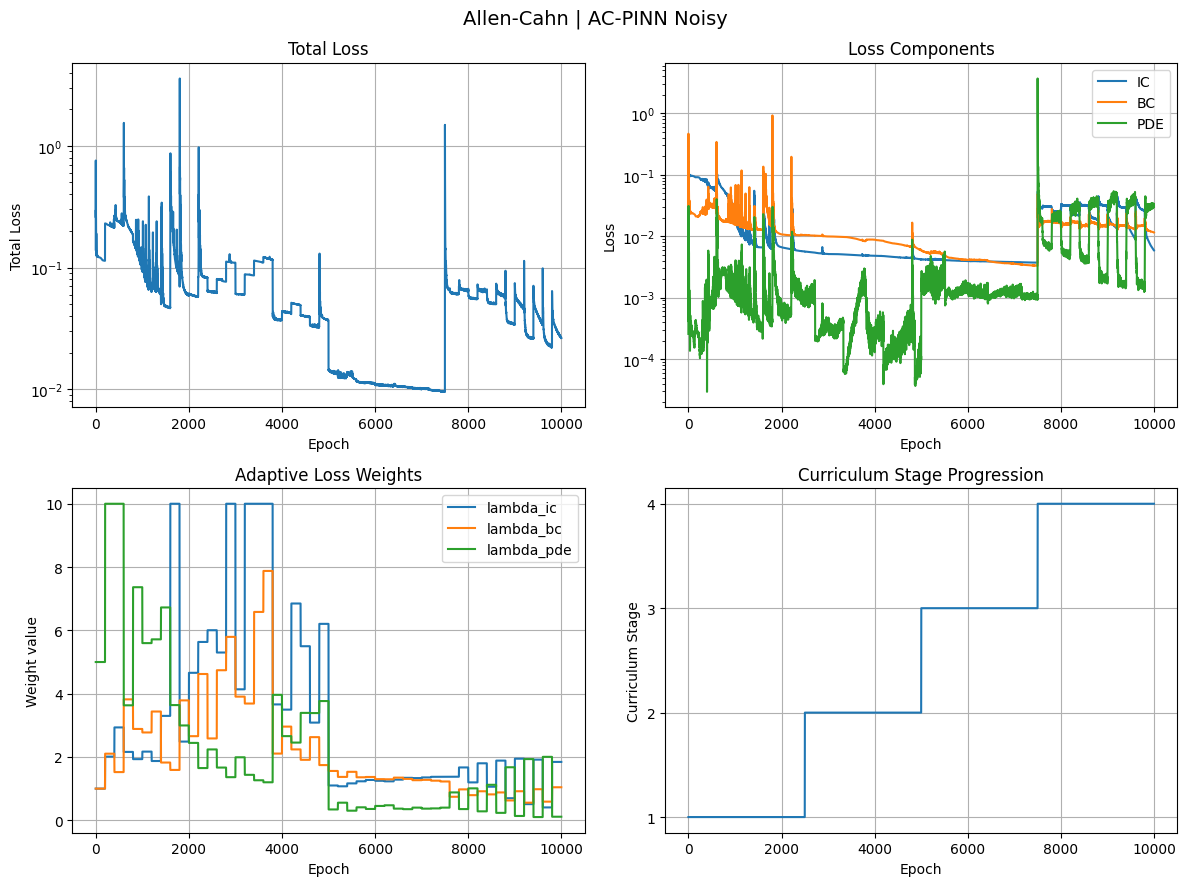

Saved: ../figures/allen_cahn/acpinn_noisy_training.png
Saved: ../figures/allen_cahn/acpinn_noisy_training.csv


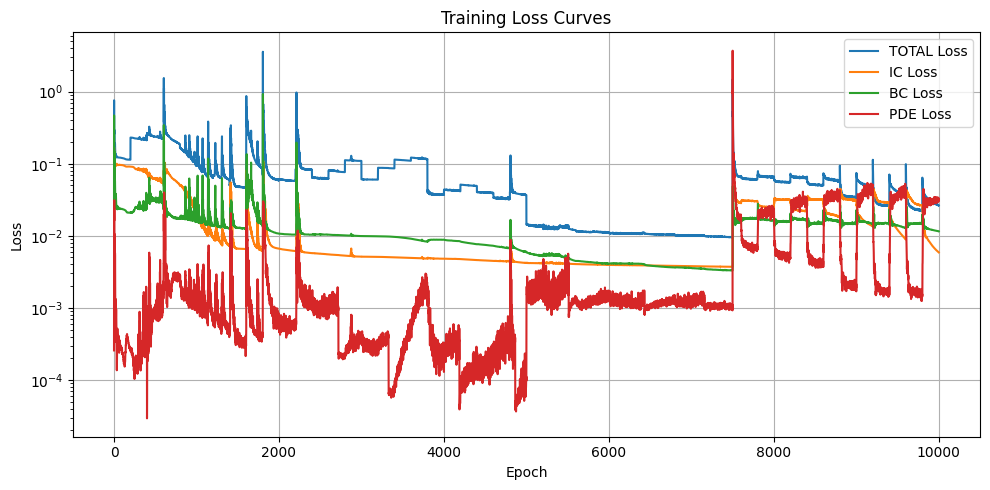

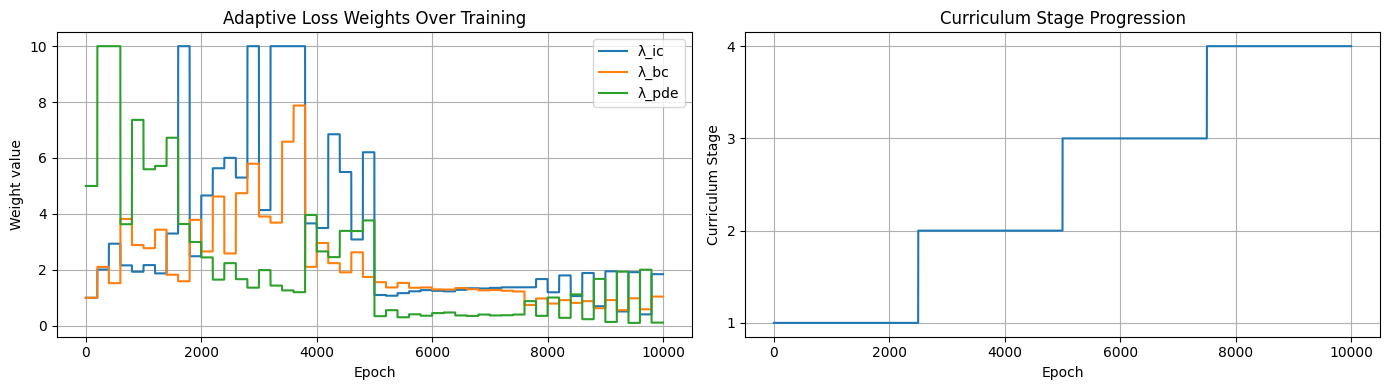

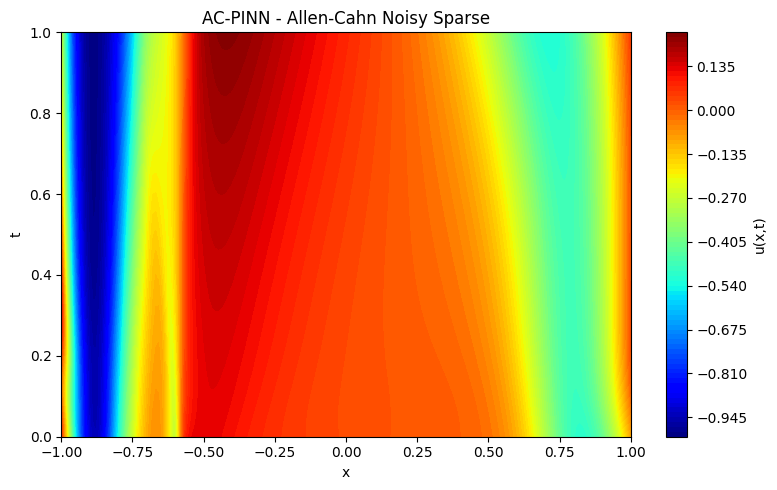

Saved: ../results/allen_cahn/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Allen-Cahn | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Allen-Cahn Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.123686   1.018543   0.031161   0.054220
  Vanilla (noisy)             0.381104   1.030766   0.094947   0.167065
  AC-PINN (clean)             0.824939   0.951265   0.234082   0.361630
  AC-PINN (noisy)             0.517854   1.043152   0.142108   0.227012


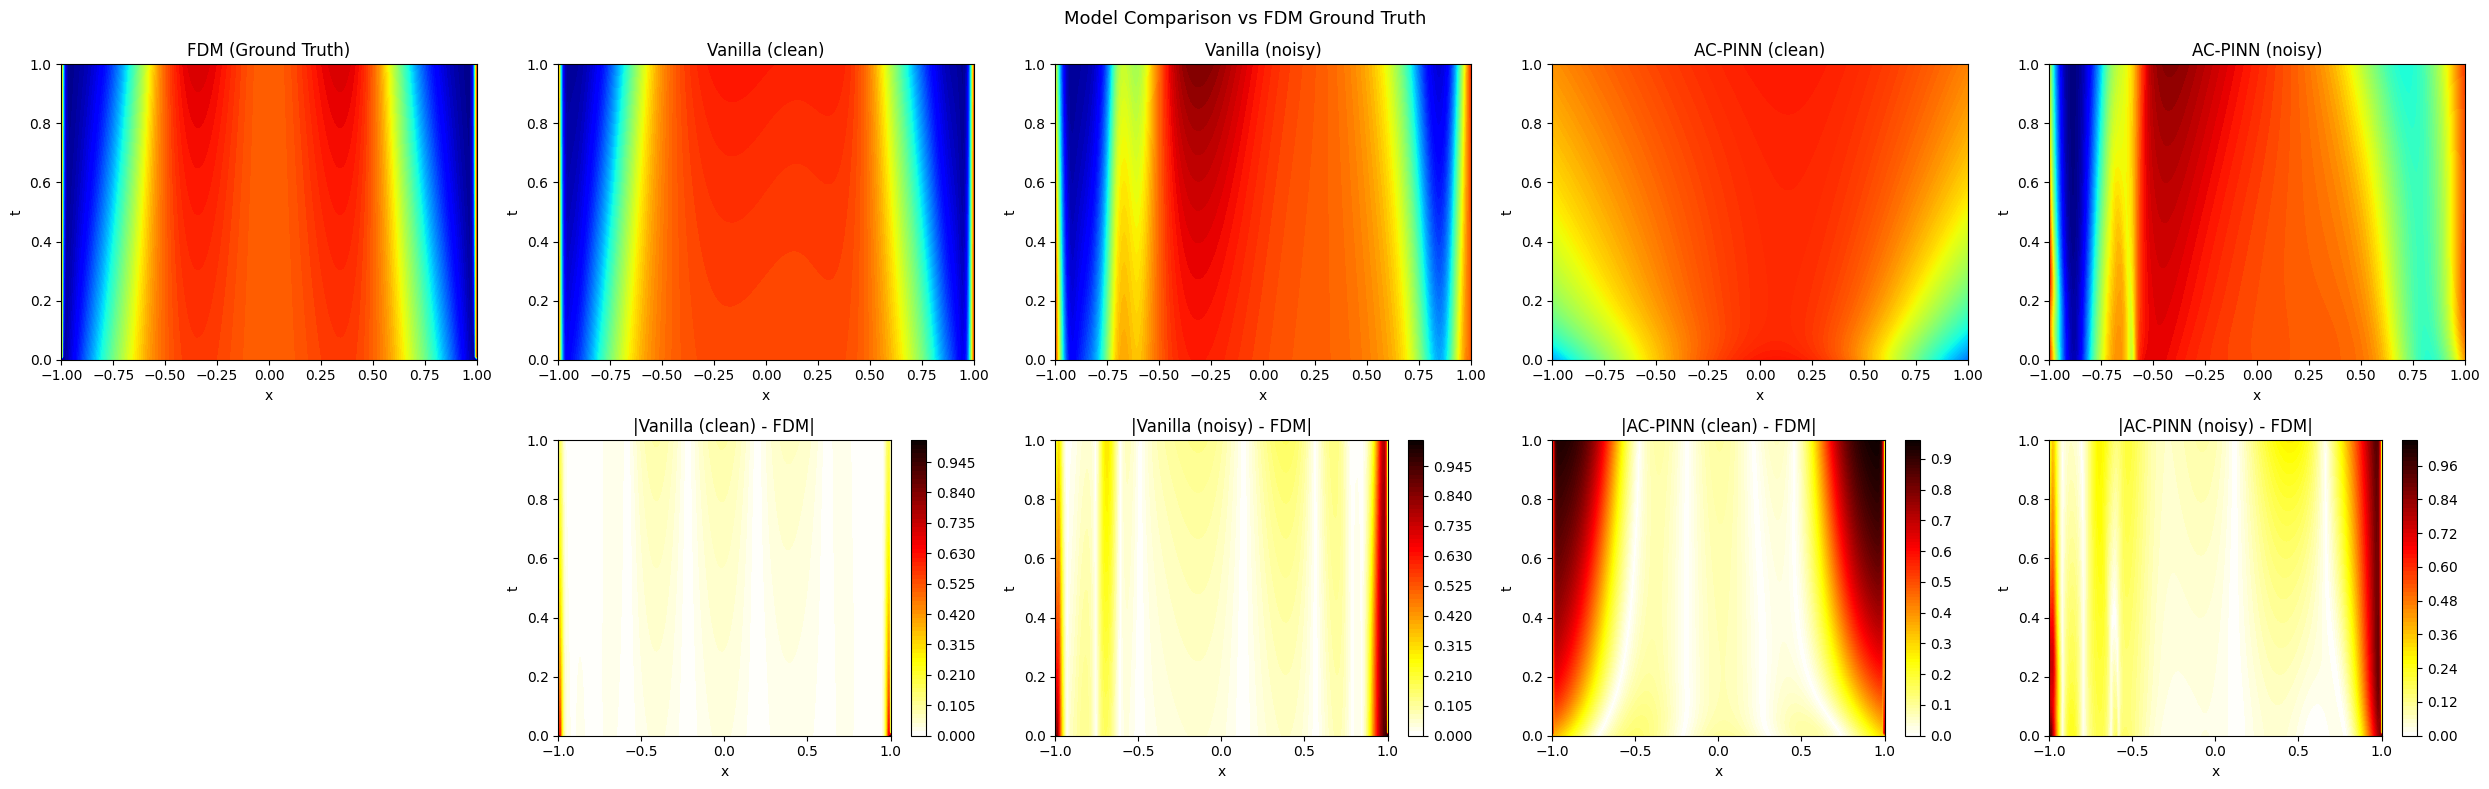

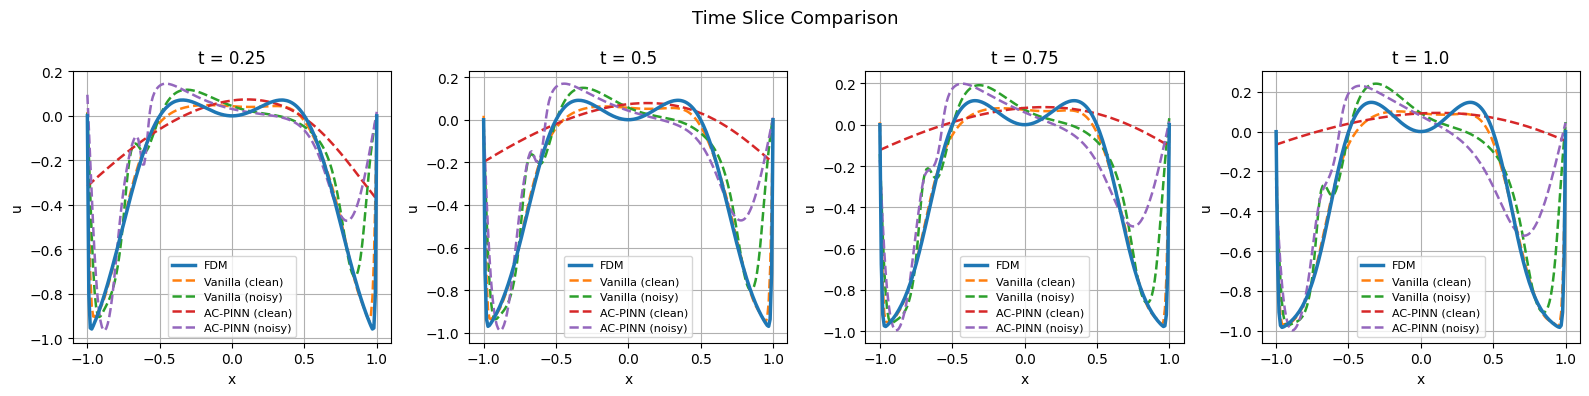

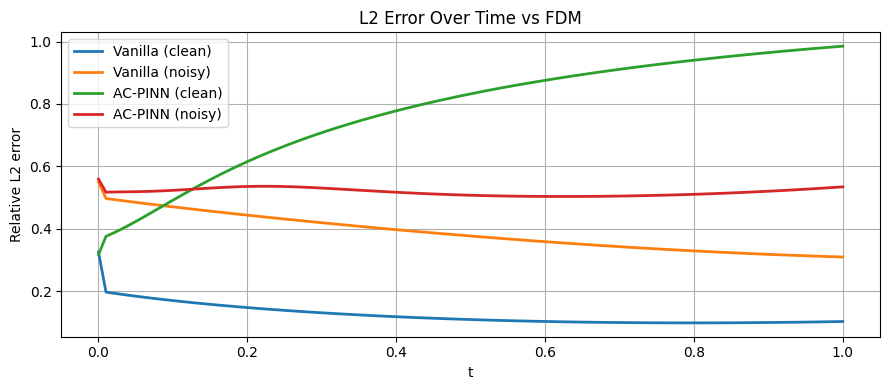

Saved: ../results/allen_cahn/benchmark_metrics.npy
Allen-Cahn experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Allen-Cahn experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=5000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, lambda_pde=10.0)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Allen-Cahn noise study complete.')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.331925 | IC: 0.064006 | BC: 0.046757 | PDE: 0.022116


[Epoch  2500/5000] Total: 0.064530 | IC: 0.056875 | BC: 0.006791 | PDE: 0.000086



Training complete in 79.18s
[Epoch     0/5000] Stage 1/4 | Total: 0.080097 | IC: 0.064081 | BC: 0.015509 | PDE: 0.000101 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.022097 | IC: 0.003240 | BC: 0.006104 | PDE: 0.000250 | lam=(2.31,1.98,10.00)



AC-PINN training complete in 85.60s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.911903   0.976216   0.291627   0.399752
  AC-PINN ε=0.05              0.798970   0.984250   0.214494   0.350245

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.559048 | IC: 0.223170 | BC: 0.142390 | PDE: 0.019349


...


AC-PINN training complete in 85.35s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.758476   0.956519   0.196179   0.332494
  AC-PINN ε=0.1               0.899992   0.996176   0.253407   0.394531

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.550808 | IC: 0.257286 | BC: 0.119490 | PDE: 0.017403


[Epoch  2500/5000] Total: 0.272919 | IC: 0.199778 | BC: 0.065155 | PDE: 0.000799



Training complete in 78.99s
[Epoch     0/5000] Stage 1/4 | Total: 0.315109 | IC: 0.254537 | BC: 0.060544 | PDE: 0.000006 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.373000 | IC: 0.033931 | BC: 0.047897 | PDE: 0.020840 | lam=(5.82,1.63,4.69)



AC-PINN training complete in 85.52s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.416805   0.998300   0.122610   0.182715
  AC-PINN ε=0.2               0.890070   0.945584   0.271567   0.390181
Saved: ../results/allen_cahn/noise_study_metrics.npy
Allen-Cahn noise study complete.
